# Homework 7

David Godovich  
4/24/2026

In [ ]:
# I don't use colab but have a fork of the class repo
# Run this to set up colab file structure
# %cd /content
# !rm -rf MOL518-Intro-to-Data-Analysis

# !git clone https://github.com/dgodovich/MOL518-Intro-to-Data-Analysis.git
# %cd MOL518-Intro-to-Data-Analysis/Homework_7

In [132]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
import scipy.ndimage as ndimage
import skimage
import cv2

# Problem 1

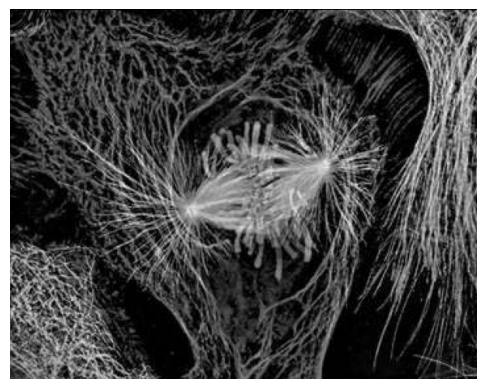

In [58]:
# a
microscopy = plt.imread('../Lecture_33/media/microscopy_example.png')
plt.imshow(microscopy)
plt.axis('off')
plt.show()

In [8]:
# b
shape = microscopy.shape
print('Array shape: ',shape)
print('Array data type: ',microscopy.dtype)
print(f'Image height: {shape[0]}; Image width: {shape[1]}')
print('Total pixels: ', shape[0]*shape[1])
print('Minimum Intensity: ', np.min(microscopy))
print('Maximum Intensity: ', np.max(microscopy))

Array shape:  (456, 576, 4)
Array data type:  float32
Image height: 456; Image width: 576
Total pixels:  262656
Minimum Intensity:  0.0
Maximum Intensity:  1.0


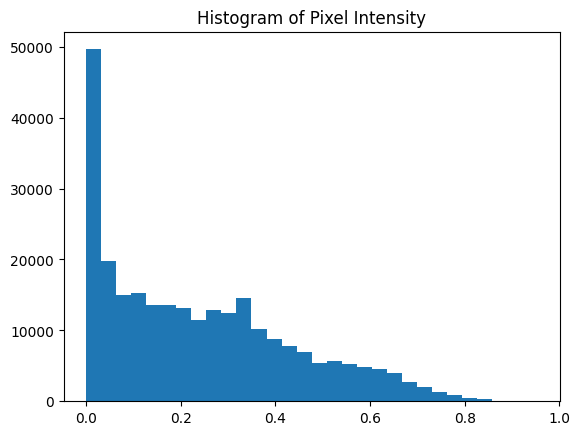

In [37]:
# c
microscopy_work = microscopy[:,:,0]
plt.hist(microscopy_work.ravel(), bins = 30)
plt.title('Histogram of Pixel Intensity')
plt.show()

Most of the pixels in the image are dark (intensity == 0). The distribution is fairly broad and extends most of the way to bright pixel values (intensity == 1). I think the image is a bit "underexposed" and does not use the full dynamic range of the detector.

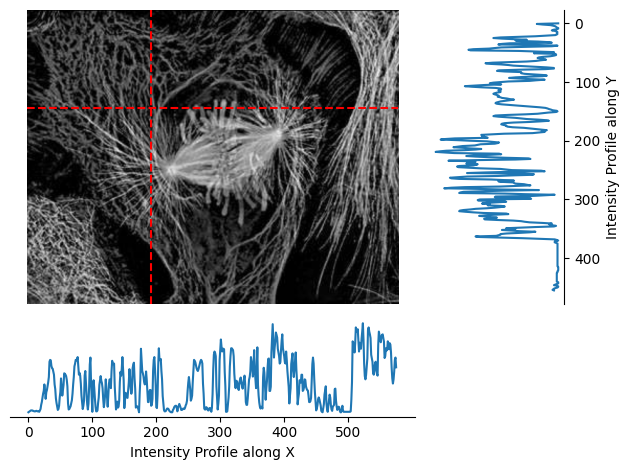

In [192]:
# d
shape = microscopy.shape
vertical = shape[1]//3
horizontal = shape[0]//3

vertical_projection = microscopy[:,vertical,0]
horizontal_projection = microscopy[horizontal,:,0]

fig, axes = plt.subplots(2,2, gridspec_kw = {'height_ratios': [3,1], 'width_ratios':[3,1]})
axes[0,0].imshow(microscopy)
axes[0,0].axvline(vertical, c = 'r', ls = '--')
axes[0,0].axhline(horizontal, c = 'r', ls = '--')
axes[0,0].axis('off')

axes[1,0].plot(horizontal_projection)
axes[1,0].yaxis.set_visible(False)
axes[1,0].spines[['top', 'left', 'right']].set_visible(False)
axes[1,0].set_xticks(range(0,shape[1],100))
axes[1,0].set_xlabel('Intensity Profile along X')

axes[0,1].plot(vertical_projection, range(shape[0])) # plot rotated to look nicer
axes[0,1].xaxis.set_visible(False)
axes[0,1].invert_xaxis() # right align to look nicer
axes[0,1].invert_yaxis()
axes[0,1].spines[['top', 'bottom', 'left']].set_visible(False)
axes[0,1].set_yticks(range(0,shape[0],100))
axes[0,1].yaxis.tick_right()
axes[0,1].set_ylabel('Intensity Profile along Y')
axes[0,1].yaxis.set_label_position("right")

axes[1,1].axis('off')

plt.tight_layout()
plt.show()

I used a line 1/3 of the way through the image for both X and Y. In the X intensity plot, we can see a dark space and then an area of high frequency, high signal on the right side of the image, which corresponds to the bundle on the right side. The highest intensity region in the middle is going through the spindle in the dividing cell.  

In the Y intensity plot, there is a region of relatively uniform intensity around 100 pixels that happens as the line goes along a fiber. There is also a high frequency high intensity area as it goes through the spindle assembly. At the bottom of the image, there is an area of uniform low intensity that corresponds to a dark region of the image.

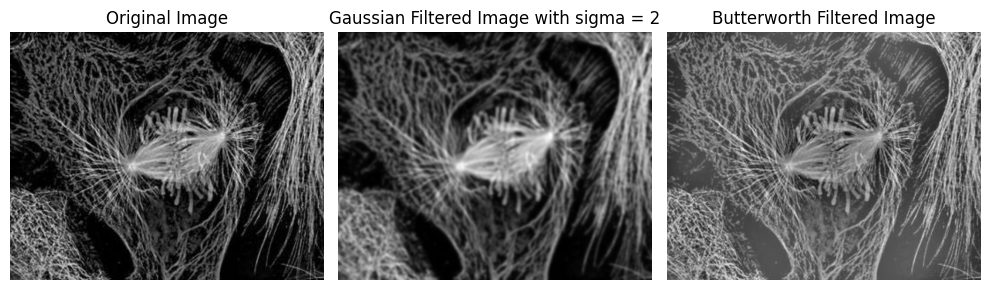

In [193]:
# e

gaussian_filter = skimage.filters.gaussian(microscopy[:,:,0], sigma = 2)
butterworth_filter = skimage.filters.butterworth(microscopy[:,:,0] )

fig, axes = plt.subplots(1,3, figsize = (10,6))
axes[0].imshow(microscopy)
axes[0].set_axis_off()
axes[0].set_title('Original Image')

axes[1].imshow(gaussian_filter, cmap = 'gray')
axes[1].set_axis_off()
axes[1].set_title('Gaussian Filtered Image with sigma = 2')

axes[2].imshow(butterworth_filter, cmap = 'gray')
axes[2].set_axis_off()
axes[2].set_title('Butterworth Filtered Image')

plt.tight_layout()
plt.show()

Idk what to say about this

# Problem 2

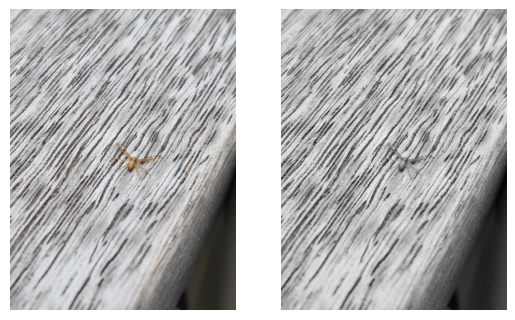

In [133]:
# a
spider = plt.imread('spider_on_table.jpg')
spider = np.rot90(spider, k = -1) # image was rotated

spider_gray = skimage.color.rgb2gray(spider)

fig, axes = plt.subplots(1,2)
axes[0].imshow(spider)
axes[0].axis('off')
axes[1].imshow(spider_gray, cmap = 'gray')
axes[1].axis('off')
plt.show()

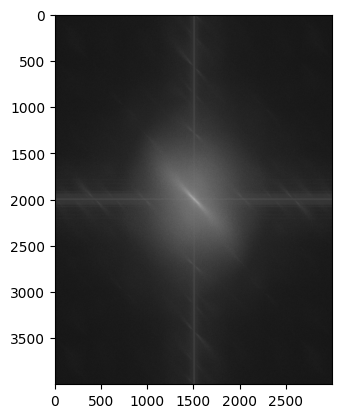

In [134]:
# b
fft2 = np.fft.fftshift(np.fft.fft2(spider_gray))
power_spectrum = np.log1p(np.abs(fft2))
plt.imshow(power_spectrum, cmap='gray');

In [143]:
# c, d
rows, cols = fft2.shape
yy, xx = np.ogrid[:rows, :cols]
cy, cx = rows // 2, cols // 2 
radius = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

low_pass_mask = radius <= 30
high_pass_mask = radius >= 50

low_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * low_pass_mask)).real
high_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * high_pass_mask)).real

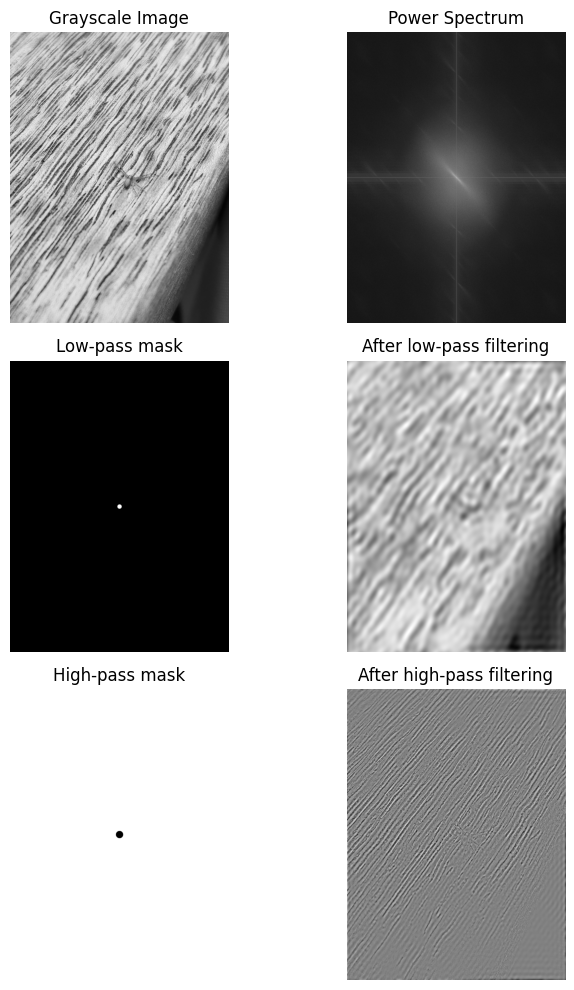

In [145]:
# e
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes[0, 0].imshow(spider_gray, cmap = 'gray')
axes[0, 0].set_title('Grayscale Image')
axes[0, 1].imshow(power_spectrum, cmap = 'gray')
axes[0, 1].set_title('Power Spectrum')
axes[1, 0].imshow(low_pass_mask, cmap='gray')
axes[1, 0].set_title('Low-pass mask')
axes[1, 1].imshow(low_pass_image, cmap='gray')
axes[1, 1].set_title('After low-pass filtering')
axes[2, 0].imshow(high_pass_mask, cmap='gray')
axes[2, 0].set_title('High-pass mask')
axes[2, 1].imshow(high_pass_image, cmap='gray')
axes[2, 1].set_title('After high-pass filtering')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()

# Problem 3

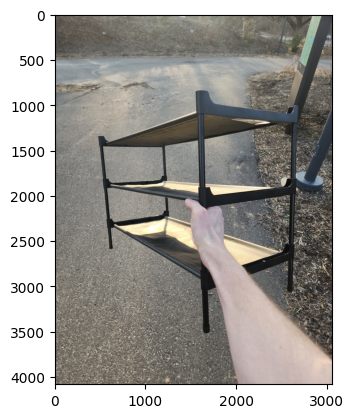

In [157]:
shoerack = plt.imread('shoerack.jpg')
shoerack = np.rot90(shoerack, k = -1)

plt.imshow(shoerack)
# plt.axis('off')
plt.show()

In [203]:
downsampled_shoe = shoerack[::5,::5]

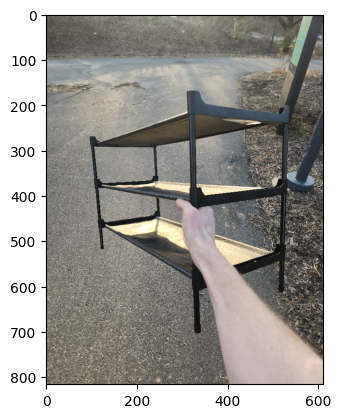

In [206]:
plt.imshow(downsampled_shoe)

#### a  
My goal is to isolate the foreground from the background of this image and segment out the shoerack and my hand.

In [207]:
shoerack_gray = skimage.color.rgb2gray(downsampled_shoe)

In [ ]:
sobel = skimage.filters.sobel(shoerack_gray)
plt.imshow(sobel)

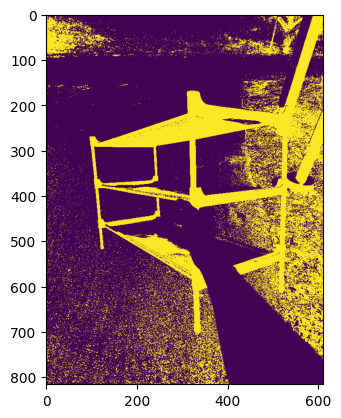

In [210]:
thresh = skimage.filters.threshold_yen(shoerack_gray)
shoerack_thresh = shoerack_gray < thresh
plt.imshow(shoerack_thresh)

In [328]:
# filtered_sobel = skimage.filters.sobel(skimage.filters.gaussian(shoerack_thresh, sigma = 3
shoerack = plt.imread('shoerack.jpg')
shoerack = np.rot90(shoerack, k = -1)
downsampled_shoe = shoerack[::5,::5]
shoerack_gray = skimage.color.rgb2gray(downsampled_shoe)
sobel = skimage.filters.sobel(shoerack_gray)

thresh = skimage.filters.threshold_yen(shoerack_gray)
gray_std = np.std(shoerack_gray)

markers = np.zeros_like(shoerack_gray, dtype = 'uint8')
foreground, background = 1, 2
markers[shoerack_gray > (thresh + gray_std)] = foreground
markers[shoerack_gray < (thresh - gray_std)] = background

ws = skimage.segmentation.watershed(sobel, markers)
seg1 = label(ws == foreground)

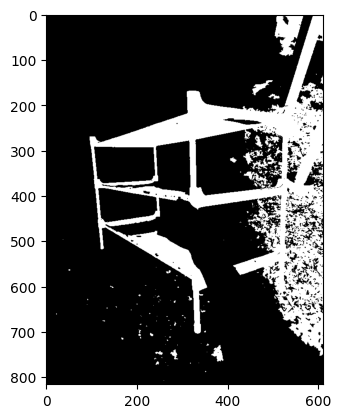

In [329]:
plt.imshow(ws, cmap = 'gray')

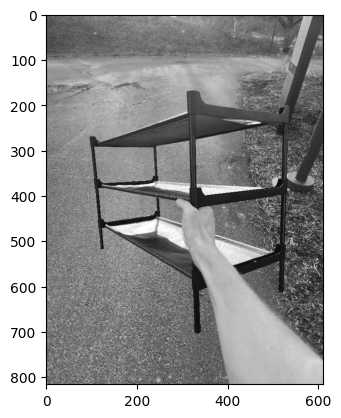

In [342]:
plt.imshow(shoerack_gray, cmap = 'gray')

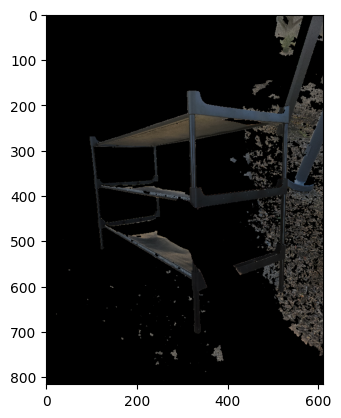

In [361]:
plt.imshow(downsampled_shoe * np.expand_dims(ws-1, axis = 2))

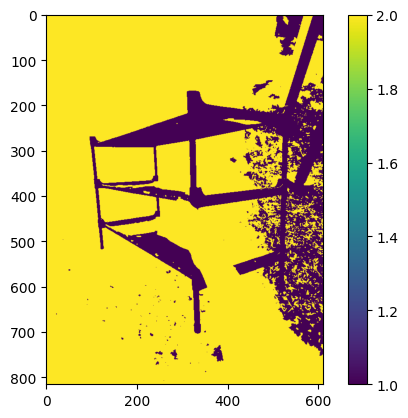

In [320]:
plt.imshow(ws)
plt.colorbar()

In [310]:
np.unique(ws)

array([1, 2], dtype=uint8)

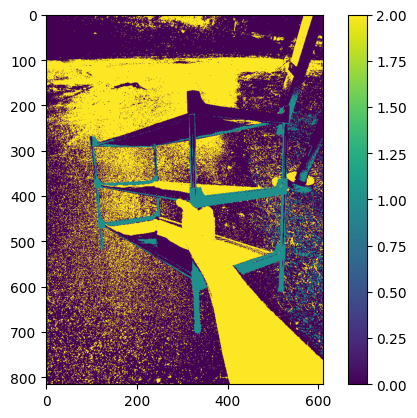

In [293]:
plt.imshow(markers)
plt.colorbar()

In [294]:
np.unique(markers)

array([0., 1., 2.])

In [299]:
coins = data.coins()

# Make segmentation using edge-detection and watershed.
edges = skimage.filters.sobel(coins)

# Identify some background and foreground pixels from the intensity values.
# These pixels are used as seeds for watershed.
markers = np.zeros_like(coins, dtype = 'uint8')
foreground, background = 1, 2
markers[coins < 30.0] = background
markers[coins > 150.0] = foreground

ws = skimage.segmentation.watershed(edges, markers)
seg1 = label(ws == foreground)

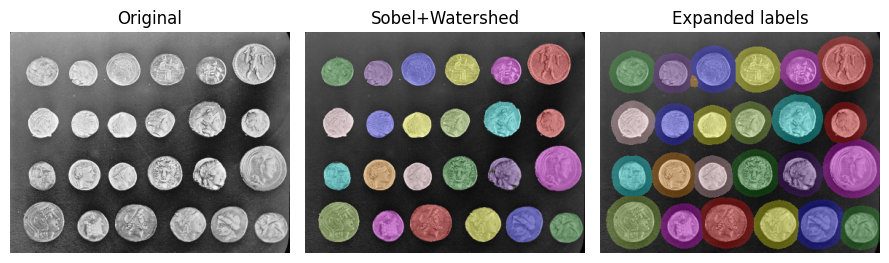

In [295]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.color import label2rgb
from skimage.filters import sobel
from skimage.measure import label
from skimage.segmentation import expand_labels, watershed

coins = data.coins()

# Make segmentation using edge-detection and watershed.
edges = sobel(coins)

# Identify some background and foreground pixels from the intensity values.
# These pixels are used as seeds for watershed.
markers = np.zeros_like(coins)
foreground, background = 1, 2
markers[coins < 30.0] = background
markers[coins > 150.0] = foreground

ws = watershed(edges, markers)
seg1 = label(ws == foreground)

expanded = expand_labels(seg1, distance=10)

# Show the segmentations.
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(9, 5),
    sharex=True,
    sharey=True,
)

axes[0].imshow(coins, cmap="Greys_r")
axes[0].set_title("Original")

color1 = label2rgb(seg1, image=coins, bg_label=0)
axes[1].imshow(color1)
axes[1].set_title("Sobel+Watershed")

color2 = label2rgb(expanded, image=coins, bg_label=0)
axes[2].imshow(color2)
axes[2].set_title("Expanded labels")

for a in axes:
    a.axis("off")
fig.tight_layout()
plt.show()

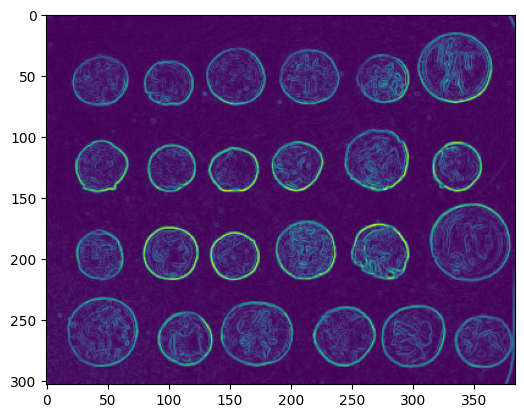

In [296]:
plt.imshow(edges)

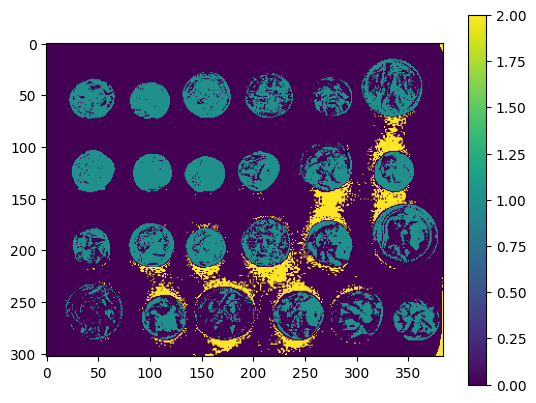

In [297]:
plt.imshow(markers)
plt.colorbar()

In [298]:
np.unique(markers)

array([0, 1, 2], dtype=uint8)